# Sistema de Recomendación de Medicamentos - INVIMA CSV + OpenFDA + KNN
## Entrega Preliminar - Opción A (Metadata + Farmacología)

Este notebook integra:
1. **Base de datos INVIMA (CSV local)** - Medicamentos registrados en Colombia
2. **OpenFDA API** - Información farmacológica completa
3. **KNN** - Búsqueda de medicamentos similares por composición
4. **Visualizaciones** - Análisis de resultados

**Nota**: 
- Descarga el CSV desde: https://www.datos.gov.co/api/v3/views/qj5z-zabx/query.json
- O usa: https://www.datos.gov.co/download/qj5z-zabx/CSV
- Coloca el archivo como: `medicamentos_invima.csv` en la carpeta del proyecto

## PASO 1: Importar Librerías Necesarias

In [254]:
# Librerías para manejo de datos
import numpy as np
import pandas as pd
import os
import json
import requests
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para procesamiento de texto y búsqueda
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Configuración de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## PASO 2: Cargar CSV del INVIMA

In [255]:
# Ruta del archivo CSV
ruta_csv = 'medicamentos_invima.csv'

# Verificar si el archivo existe
if not os.path.exists(ruta_csv):
    print(f"No se encontró: {ruta_csv}")
    print(f"\nDescargando desde datos.gov.co...")
    
    url = "https://www.datos.gov.co/api/v3/views/qj5z-zabx/query.json"
    try:
        response = requests.get(url, timeout=60)
        datos = response.json()
        df_medicamentos = pd.DataFrame(datos)
        df_medicamentos.to_csv(ruta_csv, index=False, encoding='utf-8')
        print(f"Archivo descargado y guardado como: {ruta_csv}")
    except Exception as e:
        print(f"Error en descarga: {e}")
        print(f"\nIntenta descargar manualmente desde:")
        print(f"https://www.datos.gov.co/download/qj5z-zabx/CSV")
else:
    print(f"Archivo encontrado: {ruta_csv}")

# Cargar CSV
print(f"\nCargando CSV...")
try:
    df_medicamentos = pd.read_csv(ruta_csv, encoding='utf-8')
    print(f"Carga completada")
    print(f"   - Total de medicamentos: {len(df_medicamentos):,}")
    print(f"   - Columnas disponibles: {len(df_medicamentos.columns)}")
except Exception as e:
    print(f"Error al cargar: {e}")
    print(f"Intenta con encoding diferente...")
    try:
        df_medicamentos = pd.read_csv(ruta_csv, encoding='latin-1')
        print(f"Carga completada con encoding 'latin-1'")
    except:
        df_medicamentos = pd.read_csv(ruta_csv, encoding='iso-8859-1')
        print(f"Carga completada con encoding 'iso-8859-1'")

Archivo encontrado: medicamentos_invima.csv

Cargando CSV...
Carga completada
   - Total de medicamentos: 153,523
   - Columnas disponibles: 28


## PASO 3: Explorar Estructura del CSV

In [256]:
print("INFORMACIÓN GENERAL DEL DATASET")

print(f"\nForma: {df_medicamentos.shape}")
print(f"\nColumnas disponibles ({len(df_medicamentos.columns)}):")
for idx, col in enumerate(df_medicamentos.columns, 1):
    print(f"   {idx:2d}. {col}")

print(f"\nPrimeros 3 registros:")
print(df_medicamentos.head(3))

print(f"\nTipos de datos:")
print(df_medicamentos.dtypes)

print(f"\nValores faltantes:")
print(df_medicamentos.isnull().sum())

INFORMACIÓN GENERAL DEL DATASET

Forma: (153523, 28)

Columnas disponibles (28):
    1. expediente
    2. producto
    3. titular
    4. registrosanitario
    5. fechaexpedicion
    6. fechavencimiento
    7. estadoregistro
    8. expedientecum
    9. consecutivocum
   10. cantidadcum
   11. descripcioncomercial
   12. estadocum
   13. fechaactivo
   14. fechainactivo
   15. muestramedica
   16. unidad
   17. atc
   18. descripcionatc
   19. viaadministracion
   20. concentracion
   21. principioactivo
   22. unidadmedida
   23. cantidad
   24. unidadreferencia
   25. formafarmaceutica
   26. nombrerol
   27. tiporol
   28. modalidad

Primeros 3 registros:
   expediente                     producto  \
0  19.916.871  CENTRUM SILVER CON LUTEINA.   
1  20.021.168    ACICLOVIR800 MG TABLE TAS   
2     224.165               CENTRUM JUNIOR   

                                titular        registrosanitario  \
0                         PFIZER S.A.S.  INVIMA 2011M-0000632-R1   
1  LABORATORIO

## PASO 4: Detectar y Mapear Columnas Automáticamente

In [257]:

print("Mapeando columnas del CSV...\n")

# Mapeo directo (columnas reales del CSV)
rename_dict = {
    'producto': 'nombre_comercial',
    'principioactivo': 'principio_activo',  
    'concentracion': 'concentracion',
    'formafarmaceutica': 'forma_farmaceutica',
    'viaadministracion': 'via_administracion',
    'titular': 'titular',
    'estadoregistro': 'estado_registro',
    'registrosanitario': 'registro_sanitario',
    'fechavencimiento': 'fecha_vencimiento',
    'descripcioncomercial': 'descripcion_comercial'
}

# Copiar dataframe
df = df_medicamentos.copy()

# Aplicar renombrado
df = df.rename(columns=rename_dict)

print("Columnas mapeadas:")
for viejo, nuevo in rename_dict.items():
    if viejo in df_medicamentos.columns:
        print(f"   {viejo:25s} → {nuevo}")

# Rellenar valores faltantes
columnas_a_rellenar = {
    'principio_activo': 'Desconocido',
    'nombre_comercial': 'Desconocido',
    'concentracion': 'N/A',
    'forma_farmaceutica': 'N/A',
    'via_administracion': 'N/A',
    'titular': 'N/A',
    'estado_registro': 'N/A'
}

print("\nRellenando valores faltantes:")
for col, valor_default in columnas_a_rellenar.items():
    if col in df.columns:
        df[col] = df[col].fillna(valor_default)
        print(f"{col}")

# Convertir a mayúsculas
if 'principio_activo' in df.columns:
    df['principio_activo'] = df['principio_activo'].astype(str).str.upper()
if 'nombre_comercial' in df.columns:
    df['nombre_comercial'] = df['nombre_comercial'].astype(str).str.upper()

# Remover duplicados (solo con columnas existentes)
columnas_dedup = [c for c in ['nombre_comercial', 'principio_activo', 'concentracion'] if c in df.columns]
if columnas_dedup:
    df_clean = df.drop_duplicates(subset=columnas_dedup, keep='first')
else:
    df_clean = df.drop_duplicates()

print(f"\nDatos limpios")
print(f"   - Registros iniciales: {len(df):,}")
print(f"   - Registros después de deduplicación: {len(df_clean):,}")
print(f"   - Registros eliminados: {len(df) - len(df_clean):,}")

cols_show = [c for c in ['nombre_comercial', 'principio_activo', 'concentracion', 'forma_farmaceutica', 'via_administracion'] if c in df_clean.columns]
print(f"\nPrimeros 5 registros limpiados:")
print(df_clean[cols_show].head())

print(f"\nResumen:")
for col in cols_show:
    print(f"   - {col}: {df_clean[col].nunique()} valores únicos")

Mapeando columnas del CSV...

Columnas mapeadas:
   producto                  → nombre_comercial
   principioactivo           → principio_activo
   concentracion             → concentracion
   formafarmaceutica         → forma_farmaceutica
   viaadministracion         → via_administracion
   titular                   → titular
   estadoregistro            → estado_registro
   registrosanitario         → registro_sanitario
   fechavencimiento          → fecha_vencimiento
   descripcioncomercial      → descripcion_comercial

Rellenando valores faltantes:
principio_activo
nombre_comercial
concentracion
forma_farmaceutica
via_administracion
titular
estado_registro

Datos limpios
   - Registros iniciales: 153,523
   - Registros después de deduplicación: 26,414
   - Registros eliminados: 127,109

Primeros 5 registros limpiados:
               nombre_comercial  \
0   CENTRUM SILVER CON LUTEINA.   
1     ACICLOVIR800 MG TABLE TAS   
2                CENTRUM JUNIOR   
3               MAXITROL ®

## PASO 5: Limpiar y Preparar Datos

In [258]:
# Copiar dataframe
df = df_medicamentos.copy()

# Aplicar renombrado
df = df.rename(columns=rename_dict)

# Rellenar valores faltantes
columnas_a_rellenar = {
    'principio_activo': 'Desconocido',
    'nombre_comercial': 'Desconocido',
    'concentracion': 'N/A',
    'forma_farmaceutica': 'N/A',
    'via_administracion': 'N/A',
    'titular': 'N/A',
    'estado_registro': 'N/A'
}

for col, valor_default in columnas_a_rellenar.items():
    if col in df.columns:
        df[col] = df[col].fillna(valor_default)
        print(f"{col}: rellenado")

# Convertir a mayúsculas para consistencia
if 'principio_activo' in df.columns:
    df['principio_activo'] = df['principio_activo'].astype(str).str.upper()
if 'nombre_comercial' in df.columns:
    df['nombre_comercial'] = df['nombre_comercial'].astype(str).str.upper()

# Remover duplicados
columnas_dedup = []
if 'nombre_comercial' in df.columns:
    columnas_dedup.append('nombre_comercial')
if 'principio_activo' in df.columns:
    columnas_dedup.append('principio_activo')
if 'concentracion' in df.columns:
    columnas_dedup.append('concentracion')

if columnas_dedup:
    df_clean = df.drop_duplicates(subset=columnas_dedup)
else:
    df_clean = df.drop_duplicates()

print(f"\nDatos limpios")
print(f"   - Registros iniciales: {len(df):,}")
print(f"   - Registros después de deduplicación: {len(df_clean):,}")
print(f"   - Registros eliminados: {len(df) - len(df_clean):,}")

print(f"\nPrimeros 5 registros después de limpieza:")
print(df_clean.head())

principio_activo: rellenado
nombre_comercial: rellenado
concentracion: rellenado
forma_farmaceutica: rellenado
via_administracion: rellenado
titular: rellenado
estado_registro: rellenado

Datos limpios
   - Registros iniciales: 153,523
   - Registros después de deduplicación: 26,414
   - Registros eliminados: 127,109

Primeros 5 registros después de limpieza:
   expediente              nombre_comercial  \
0  19.916.871   CENTRUM SILVER CON LUTEINA.   
1  20.021.168     ACICLOVIR800 MG TABLE TAS   
2     224.165                CENTRUM JUNIOR   
3  19.900.530               MAXITROL ® PLUS   
4  19.968.974  CALCIUM600. VITAMIN DTABLETS   

                                titular       registro_sanitario  \
0                         PFIZER S.A.S.  INVIMA 2011M-0000632-R1   
1  LABORATORIOSRICHMOND COLOMBIA S.A.S.     INVIMA 2011M-0012292   
2                         PFIZER S.A.S.  INVIMA 2008 M-007219 R1   
3               ALCON LABORATORIES INC.          INVIMA M-012628   
4    GOOD`N NAT

## PASO 6: Crear Embeddings de Medicamentos (TF-IDF)

In [259]:
def crear_embeddings_medicamentos(df):
    """
    Crea vectores TF-IDF basados en características clínicas del medicamento.
    """
    print("Creando embeddings de medicamentos...\n")

    caracteristicas_disponibles = []
    for col in ['principio_activo', 'concentracion', 'forma_farmaceutica', 'via_administracion']:
        if col in df.columns:
            caracteristicas_disponibles.append(col)
            print(f"Usando: {col}")

    df['caracteristicas'] = ''
    for col in caracteristicas_disponibles:
        df['caracteristicas'] = df['caracteristicas'] + ' ' + df[col].fillna('').astype(str)

    vectorizer = TfidfVectorizer(
        analyzer='char',
        ngram_range=(2, 3),
        max_features=5000,
        lowercase=True
    )

    vectores = vectorizer.fit_transform(df['caracteristicas'])

    print(f"\nEmbeddings creados")
    print(f"   - Forma de matriz: {vectores.shape}")
    print(f"   - Dimensionalidad: {vectores.shape[1]} características")
    print(f"   - Densidad: {vectores.nnz / (vectores.shape[0] * vectores.shape[1]):.4f}")

    return vectores, vectorizer, df

# Crear embeddings
vectores, vectorizer, df_clean = crear_embeddings_medicamentos(df_clean)

Creando embeddings de medicamentos...

Usando: principio_activo
Usando: concentracion
Usando: forma_farmaceutica
Usando: via_administracion

Embeddings creados
   - Forma de matriz: (26414, 5000)
   - Dimensionalidad: 5000 características
   - Densidad: 0.0187


## PASO 7: Entrenar Modelo KNN

In [260]:
def entrenar_knn(vectores, n_neighbors=6):
    """
    Entrena modelo KNN para búsqueda de similitud
    """
    print("Entrenando modelo KNN...\n")
    
    knn = NearestNeighbors(
        n_neighbors=n_neighbors,
        algorithm='brute',
        metric='cosine'
    )
    
    knn.fit(vectores)
    
    print(f"Modelo KNN entrenado")
    print(f"   - Algoritmo: Brute Force")
    print(f"   - Métrica: Cosine Similarity")
    print(f"   - Vecinos: {n_neighbors}")
    print(f"   - Muestras indexadas: {vectores.shape[0]:,}")
    
    return knn

# Entrenar
knn_model = entrenar_knn(vectores, n_neighbors=6)

Entrenando modelo KNN...

Modelo KNN entrenado
   - Algoritmo: Brute Force
   - Métrica: Cosine Similarity
   - Vecinos: 6
   - Muestras indexadas: 26,414


## PASO 8: Función para Obtener Información de OpenFDA

In [261]:
import requests
import time
from datetime import datetime

# Cache para evitar solicitudes repetidas
cache_openfda = {}
cache_wikipedia = {}

# Diccionario de traducción Español -> Inglés para OpenFDA
TRADUCCION_ES_EN = {
    "ACETAMINOFEN": "acetaminophen",
    "ACETAMINOFÉN": "acetaminophen",
    "IBUPROFENO": "ibuprofen",
    "NAPROXENO": "naproxen",
    "PARACETAMOL": "paracetamol",
    "DICLOFENACO": "diclofenac",
    "DICLOFENACO SODICO": "diclofenac sodium",
    "DICLOFENACO POTASICO": "diclofenac potassium",
    "AMOXICILINA": "amoxicillin",
    "AMOXICILINA TRIHYDRATE": "amoxicillin",
    "CEFALEXINA": "cephalexin",
    "METFORMINA": "metformin",
    "ATORVASTATINA": "atorvastatin",
    "SIMVASTATINA": "simvastatin",
    "OMEPRAZOL": "omeprazole",
    "PANTOPRAZOL": "pantoprazole",
    "LORATADINA": "loratadine",
    "LOSARTAN": "losartan",
    "LOSARTAN POTASICO": "losartan potassium",
    "LISINOPRIL": "lisinopril",
    "ATENOLOL": "atenolol",
    "GABAPENTINA": "gabapentin",
    "CLARITROMICINA": "clarithromycin",
    "ACIDO ASCORBICO": "ascorbic acid",
    "ÁCIDO ASCÓRBICO": "ascorbic acid",
    "VITAMINA C": "ascorbic acid",
    "ACIDO FOLICO": "folic acid",
    "ÁCIDO FÓLICO": "folic acid",
    "VITAMINA B12": "cyanocobalamin",
    "CIANOCOBALAMINA": "cyanocobalamin",
    "VITAMINA D": "cholecalciferol",
    "CLOTRIMAZOL": "clotrimazole",
    "CLORURO DE SODIO": "sodium chloride",
    "PIRIDOXINA CLORHIDRATO": "pyridoxine hydrochloride",
    "PIRIDOXINA": "pyridoxine",
    "NICOTINAMIDA": "nicotinamide",
    "CIPROFLOXACINA": "ciprofloxacin",
    "AZITROMICINA": "azithromycin",
    "DEXAMETASONA": "dexamethasone",
    "PREDNISONA": "prednisone",
    "SALBUTAMOL": "albuterol",
    "RANITIDINA": "ranitidine",
    "METOCLOPRAMIDA": "metoclopramide",
    "DIPIRONA": "dipyrone",
    "METAMIZOL": "metamizole",
    "TRAMADOL": "tramadol",
    "CODEINA": "codeine",
    "FOSFATO DE CODEINA": "codeine phosphate",
    "AMLODIPINA": "amlodipine",
    "FUROSEMIDA": "furosemide",
    "ESPIRONOLACTONA": "spironolactone",
    "WARFARINA": "warfarin",
    "ASPIRINA": "aspirin",
    "ACIDO ACETILSALICILICO": "aspirin",
    "FLUCONAZOL": "fluconazole",
    "METRONIDAZOL": "metronidazole",
    "ERITROMICINA": "erythromycin",
    "DOXICICLINA": "doxycycline",
    "TETRACICLINA": "tetracycline",
    "GENTAMICINA": "gentamicin",
    "AMPICILINA": "ampicillin",
    "PENICILINA": "penicillin",
    "INSULINA": "insulin",
    "GLIBENCLAMIDA": "glibenclamide",
    "GLIPIZIDA": "glipizide",
    "LEVOTIROXINA": "levothyroxine",
    "PROPRANOLOL": "propranolol",
    "CAPTOPRIL": "captopril",
    "ENALAPRIL": "enalapril",
    "NIFEDIPINA": "nifedipine",
    "VERAPAMILO": "verapamil",
    "DILTIAZEM": "diltiazem",
    "ALPRAZOLAM": "alprazolam",
    "DIAZEPAM": "diazepam",
    "LORAZEPAM": "lorazepam",
    "HALOPERIDOL": "haloperidol",
    "RISPERIDONA": "risperidone",
    "SERTRALINA": "sertraline",
    "FLUOXETINA": "fluoxetine",
    "AMITRIPTILINA": "amitriptyline",
    "CARBAMAZEPINA": "carbamazepine",
    "ACIDO VALPROICO": "valproic acid",
    "MORFINA": "morphine",
    "CLOPIDOGREL": "clopidogrel",
    "TIAMINA": "thiamine",
    "RIBOFLAVINA": "riboflavin",
    "ACIDO PANTOTENICO": "pantothenic acid",
    "CALCIO CARBONATO": "calcium carbonate",
    "SULFATO FERROSO": "ferrous sulfate",
    "HIERRO SULFATO": "ferrous sulfate",
    "CETIRIZINA": "cetirizine",
    "FEXOFENADINA": "fexofenadine",
    "MONTELUKAST": "montelukast",
    "BUDESONIDA": "budesonide",
    "BECLOMETASONA": "beclomethasone",
    "FLUTICASONA": "fluticasone",
    "FORMOTEROL": "formoterol",
    "SALMETEROL": "salmeterol",
    "TERBUTALINA": "terbutaline",
    "IPRATROPIO": "ipratropium",
    "NITROGLICERINA": "nitroglycerin",
    "ISOSORBIDA": "isosorbide",
    "DIGOXINA": "digoxin",
    "AMIODARONA": "amiodarone",
    "HIDROCLOROTIAZIDA": "hydrochlorothiazide",
    "TORASEMIDA": "torasemide",
    "METOPROLOL": "metoprolol",
    "CARVEDILOL": "carvedilol",
    "BISOPROLOL": "bisoprolol",
    "IRBESARTAN": "irbesartan",
    "VALSARTAN": "valsartan",
    "CANDESARTAN": "candesartan",
    "TELMISARTAN": "telmisartan",
    "RAMIPRIL": "ramipril",
    "PERINDOPRIL": "perindopril",
    "ROSUVASTATINA": "rosuvastatin",
    "PRAVASTATINA": "pravastatin",
    "FLUVASTATINA": "fluvastatin",
    "EZETIMIBA": "ezetimibe",
    "FENOFIBRATO": "fenofibrate",
    "GEMFIBROZILO": "gemfibrozil",
    "ACARBOSA": "acarbose",
    "PIOGLITAZONA": "pioglitazone",
    "SITAGLIPTINA": "sitagliptin",
    "VILDAGLIPTINA": "vildagliptin",
    "SAXAGLIPTINA": "saxagliptin",
    "LIRAGLUTIDA": "liraglutide",
    "DAPAGLIFLOZINA": "dapagliflozin",
    "EMPAGLIFLOZINA": "empagliflozin",
    "CLONAZEPAM": "clonazepam",
    "OXCARBAZEPINA": "oxcarbazepine",
    "LAMOTRIGINA": "lamotrigine",
    "LEVETIRACETAM": "levetiracetam",
    "TOPIRAMATO": "topiramate",
    "FENITOINA": "phenytoin",
    "FENOBARBITAL": "phenobarbital",
    "BUPROPION": "bupropion",
    "VENLAFAXINA": "venlafaxine",
    "DULOXETINA": "duloxetine",
    "ESCITALOPRAM": "escitalopram",
    "CITALOPRAM": "citalopram",
    "PAROXETINA": "paroxetine",
    "CLOMIPRAMINA": "clomipramine",
    "IMIPRAMINA": "imipramine",
    "QUETIAPINA": "quetiapine",
    "OLANZAPINA": "olanzapine",
    "CLOZAPINA": "clozapine",
    "ARIPIPRAZOL": "aripiprazole",
    "ZIPRASIDONA": "ziprasidone",
    "MIRTAZAPINA": "mirtazapine",
    "TRAZODONA": "trazodone",
    "ZOLPIDEM": "zolpidem",
    "MELATONINA": "melatonin",
    "DONEPEZILO": "donepezil",
    "MEMANTINA": "memantine",
    "RIVASTIGMINA": "rivastigmine",
    "GALANTAMINA": "galantamine",
    "ONDANSETRON": "ondansetron",
    "DOMPERIDONA": "domperidone",
    "DIFENHIDRAMINA": "diphenhydramine",
    "CLORFENAMINA": "chlorpheniramine",
    "PROMETAZINA": "promethazine",
    "PANTOPRAZOL": "pantoprazole",
    "LANSOPRAZOL": "lansoprazole",
    "ESOMEPRAZOL": "esomeprazole",
    "SUCRALFATO": "sucralfate",
    "MISOPROSTOL": "misoprostol",
    "LOPERAMIDA": "loperamide",
    "MESALAZINA": "mesalamine",
    "SULFASALAZINA": "sulfasalazine",
    "AZATIOPRINA": "azathioprine",
    "METOTREXATO": "methotrexate",
    "LEFLUNOMIDA": "leflunomide",
    "HIDROXICLOROQUINA": "hydroxychloroquine",
    "ALOPURINOL": "allopurinol",
    "COLCHICINA": "colchicine",
    "OXACILINA": "oxacillin",
    "CLOXACILINA": "cloxacillin",
    "DICLOXACILINA": "dicloxacillin",
    "CEFAZOLINA": "cefazolin",
    "CEFTRIAXONA": "ceftriaxone",
    "CEFUROXIMA": "cefuroxime",
    "CEFIXIMA": "cefixime",
    "IMIPENEM": "imipenem",
    "MEROPENEM": "meropenem",
    "VANCOMICINA": "vancomycin",
    "LINEZOLID": "linezolid",
    "NITROFURANTOINA": "nitrofurantoin",
    "TRIMETOPRIM": "trimethoprim",
    "COTRIMOXAZOL": "trimethoprim-sulfamethoxazole",
    "ACICLOVIR": "acyclovir",
    "VALACICLOVIR": "valacyclovir",
    "OSELTAMIVIR": "oseltamivir",
    "FLUCONAZOL": "fluconazole",
    "ITRACONAZOL": "itraconazole",
    "VORICONAZOL": "voriconazole",
    "ALBENDAZOL": "albendazole",
    "MEBENDAZOL": "mebendazole",
    "IVERMECTINA": "ivermectin",
    "RETINOL": "retinol",
    "VITAMINA A": "retinol",
    "VITAMINA E": "tocopherol",
    "VITAMINA K": "phytonadione",
    "CALCIO": "calcium",
    "MAGNESIO": "magnesium",
    "ZINC": "zinc",
    "HIERRO": "iron",
    "YODO": "iodine",
    "SELENIO": "selenium",
    "CROMO": "chromium",
    "MANGANESO": "manganese",
    "COBRE": "copper",
    "HEPARINA": "heparin",
    "ENOXAPARINA": "enoxaparin",
    "RIVAROXABAN": "rivaroxaban",
    "APIXABAN": "apixaban",
    "DABIGATRAN": "dabigatran",
    "ALTEPLASA": "alteplase",
    "ESTREPTOQUINASA": "streptokinase",
    "ERITROPOYETINA": "erythropoietin",
    "FILGRASTIM": "filgrastim",
    "TACROLIMUS": "tacrolimus",
    "CICLOSPORINA": "cyclosporine",
    "MICOFENOLATO": "mycophenolate",
    "SIROLIMUS": "sirolimus",
    "TESTOSTERONA": "testosterone",
    "ESTRADIOL": "estradiol",
    "PROGESTERONA": "progesterone",
    "LEVONORGESTREL": "levonorgestrel",
    "MEDROXIPROGESTERONA": "medroxyprogesterone",
    "OXITOCINA": "oxytocin",
    "ERGOTAMINA": "ergotamine",
    "CABERGOLINA": "cabergoline",
    "BROMOCRIPTINA": "bromocriptine",
}

def obtener_info_completa(nombre_principio_activo, timeout=10):
    """
    Obtiene información de OpenFDA para un principio activo.
    Traduce el nombre de español a inglés antes de consultar.
    Intenta múltiples estrategias de búsqueda.
    """

    nombre_key = nombre_principio_activo.upper().strip()
    if nombre_key in cache_openfda:
        return cache_openfda[nombre_key]

    info = {
        "nombre": nombre_key,
        "encontrado": False,
        "encontrado_openfda": False,
        "indicaciones": "No disponible",
        "contraindicaciones": "No disponible",
        "advertencias": "No disponible",
        "efectos_adversos": "No disponible",
        "dosis": "No disponible",
        "descripcion": "No disponible",
        "fuente": "Sin información"
    }

    nombre_en = TRADUCCION_ES_EN.get(nombre_key, nombre_principio_activo.lower().strip())

    print(f"Buscando en OpenFDA: {nombre_key} → EN: {nombre_en}...")

    estrategias = [
        f'https://api.fda.gov/drug/label.json?search=openfda.substance_name:"{nombre_en}"&limit=1',
        f'https://api.fda.gov/drug/label.json?search=openfda.generic_name:"{nombre_en}"&limit=1',
        f'https://api.fda.gov/drug/label.json?search=active_ingredients.name:"{nombre_en}"&limit=1',
    ]

    for url in estrategias:
        try:
            response = requests.get(url, timeout=timeout)

            if response.status_code == 200:
                datos = response.json()

                if datos.get("results") and len(datos["results"]) > 0:
                    resultado = datos["results"][0]

                    info["encontrado"] = True
                    info["encontrado_openfda"] = True
                    info["fuente"] = "OpenFDA"

                    if resultado.get("indications_and_usage"):
                        info["indicaciones"] = resultado["indications_and_usage"][0][:500]

                    if resultado.get("warnings"):
                        info["contraindicaciones"] = resultado["warnings"][0][:300]
                        info["advertencias"] = info["contraindicaciones"]

                    if resultado.get("adverse_reactions"):
                        info["efectos_adversos"] = resultado["adverse_reactions"][0][:300]

                    if resultado.get("dosage_and_administration"):
                        info["dosis"] = resultado["dosage_and_administration"][0][:300]

                    if resultado.get("description"):
                        info["descripcion"] = resultado["description"][0][:300]

                    print(f"Información encontrada en OpenFDA")
                    cache_openfda[nombre_key] = info
                    return info

        except Exception as e:
            print(f"Error en OpenFDA: {str(e)}")

    print(f"No encontrado en OpenFDA para: {nombre_key}")
    cache_openfda[nombre_key] = info
    return info

In [262]:
def obtener_info_wikipedia(nombre_principio_activo, timeout=5):
    """
    Obtiene información de Wikipedia como respaldo
    """

    nombre_key = nombre_principio_activo.upper()
    if nombre_key in cache_wikipedia:
        return cache_wikipedia[nombre_key]

    info = {
        "nombre": nombre_key,
        "encontrado": False,
        "descripcion": "No disponible",
        "usos": "No disponible",
        "efectos": "No disponible",
        "fuente": "Sin información"
    }

    # Traducir a inglés para Wikipedia
    nombre_en = TRADUCCION_ES_EN.get(nombre_key, nombre_principio_activo)

    try:
        print(f"Buscando en Wikipedia: {nombre_en}...")

        url = "https://en.wikipedia.org/w/api.php"
        params = {
            "action": "query",
            "format": "json",
            "titles": nombre_en,
            "prop": "extracts",
            "explaintext": True,
            "redirects": 1
        }

        response = requests.get(url, params=params, timeout=timeout)
        response.raise_for_status()
        datos = response.json()

        pages = datos.get("query", {}).get("pages", {})
        for page_id, page_data in pages.items():
            if page_id != "-1" and "extract" in page_data:
                extracto = page_data["extract"]

                info["encontrado"] = True
                info["fuente"] = "Wikipedia"

                lineas = extracto.split("\n")[:10]
                info["descripcion"] = " ".join(lineas)[:500]

                print(f"Información encontrada en Wikipedia")
                cache_wikipedia[nombre_key] = info
                return info

    except Exception as e:
        print(f"Error en Wikipedia: {str(e)}")

    print(f"No encontrado en Wikipedia")
    cache_wikipedia[nombre_key] = info
    return info

In [263]:
def mostrar_informacion_medicamento(principios_activos):
    """
    Muestra información completa del medicamento
    """

    print("\n" + "="*80)
    print("INFORMACIÓN COMPLETA DEL MEDICAMENTO".center(80))
    print("="*80 + "\n")

    for principio_activo in principios_activos:
        print(f"\nPrincipio Activo: {principio_activo}")
        print("-" * 80)

        info_openfda = obtener_info_completa(principio_activo)

        if info_openfda["encontrado_openfda"]:
            print(f"\nFuente: {info_openfda['fuente']}")
            print(f"\n✓ Indicaciones:")
            print(f"   {info_openfda['indicaciones'][:200]}...")
            print(f"\n✓ Dosis:")
            print(f"   {info_openfda['dosis'][:200]}...")
            print(f"\n✓ Contraindicaciones/Advertencias:")
            print(f"   {info_openfda['contraindicaciones'][:200]}...")
            print(f"\n✓ Efectos Adversos:")
            print(f"   {info_openfda['efectos_adversos'][:200]}...")
        else:
            print(f"\n   Buscando información alternativa...")
            info_wiki = obtener_info_wikipedia(principio_activo)

            if info_wiki["encontrado"]:
                print(f"\nFuente: {info_wiki['fuente']}")
                print(f"\n✓ Descripción:")
                print(f"   {info_wiki['descripcion'][:300]}...")
            else:
                print(f" No se encontró información disponible")

        time.sleep(0.5)

    print("\n" + "="*80 + "\n")


def obtener_estadisticas(principios_activos):
    """
    Obtiene estadísticas de los medicamentos buscados
    """

    print("\n" + "="*80)
    print("ESTADÍSTICAS DE BÚSQUEDA".center(80))
    print("="*80 + "\n")

    encontrados_openfda = sum(1 for p in principios_activos if obtener_info_completa(p)["encontrado_openfda"])
    encontrados_total = len(principios_activos)
    porcentaje = (encontrados_openfda / encontrados_total * 100) if encontrados_total > 0 else 0

    print(f"✓ Medicamentos buscados: {encontrados_total}")
    print(f"✓ Encontrados en OpenFDA: {encontrados_openfda}")
    print(f"✓ Porcentaje de cobertura: {porcentaje:.1f}%")
    print(f"✓ Fecha de consulta: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
    print(f"✓ Items en caché: {len(cache_openfda)} (OpenFDA) + {len(cache_wikipedia)} (Wikipedia)")

    print("\n" + "="*80 + "\n")


def exportar_informacion(principios_activos, archivo="medicamentos_info.txt"):
    """
    Exporta la información a un archivo
    """

    try:
        with open(archivo, "w", encoding="utf-8") as f:
            f.write("="*80 + "\n")
            f.write("INFORMACIÓN DE MEDICAMENTOS\n")
            f.write("="*80 + "\n\n")
            f.write(f"Fecha de generación: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}\n\n")

            for principio_activo in principios_activos:
                info = obtener_info_completa(principio_activo)

                f.write(f"\n{'='*80}\n")
                f.write(f"MEDICAMENTO: {info['nombre']}\n")
                f.write(f"{'='*80}\n")
                f.write(f"Fuente: {info['fuente']}\n")
                f.write(f"Encontrado: {'Sí' if info['encontrado'] else 'No'}\n\n")

                f.write(f"INDICACIONES:\n{info['indicaciones']}\n\n")
                f.write(f"DOSIS:\n{info['dosis']}\n\n")
                f.write(f"CONTRAINDICACIONES:\n{info['contraindicaciones']}\n\n")
                f.write(f"EFECTOS ADVERSOS:\n{info['efectos_adversos']}\n\n")

        print(f"Información exportada a: {archivo}")
    except Exception as e:
        print(f"Error al exportar: {str(e)}")

In [ ]:
# EJEMPLO DE USO con openFDA (implementación no colocada en el main de la IA, pero se muestra cómo se usaría)
if __name__ == "__main__":

    medicamentos = [
        "Gabapentin",
        "Clarithromycin",
        "Naproxen",
        "Acetaminophen",
        "Ibuprofen",
        "Amoxicillin"
    ]

    mostrar_informacion_medicamento(medicamentos)
    obtener_estadisticas(medicamentos)
    exportar_informacion(medicamentos)

    print("\nCACHÉ DE OPENFDA:")
    print("-" * 80)
    for medicina, info in cache_openfda.items():
        estado = "Encontrado" if info["encontrado_openfda"] else "❌ No encontrado"
        print(f"  {medicina}: {estado}")

    print("\nCACHÉ DE WIKIPEDIA:")
    print("-" * 80)
    for medicina, info in cache_wikipedia.items():
        estado = "Encontrado" if info["encontrado"] else "❌ No encontrado"
        print(f"  {medicina}: {estado}")


                      INFORMACIÓN COMPLETA DEL MEDICAMENTO                      


Principio Activo: Gabapentin
--------------------------------------------------------------------------------

Fuente: OpenFDA

✓ Indicaciones:
   1 INDICATIONS AND USAGE Gabapentin Capsules, USP are indicated for: Management of postherpetic neuralgia in adults Adjunctive therapy in the treatment of partial onset seizures, with and without secon...

✓ Dosis:
   2 DOSAGE AND ADMlNlSTRATION Postherpetic Neuralgia (2.1) Dose can be titrated up as needed to a dose of 1800 mg/day Day 1: Single 300 mg dose Day 2: 600 mg/day (i.e., 300 mg two times a day) Day 3: 90...

✓ Contraindicaciones/Advertencias:
   No disponible...

✓ Efectos Adversos:
   6 ADVERSE REACTIONS The following serious adverse reactions are discussed in greater detail in other sections: Drug Reaction with Eosinophilia and Systemic Symptoms (DRESS)/Multiorgan Hypersensitivity...

Principio Activo: Clarithromycin
------------------------------

## PASO 9: Función Principal de Recomendación Completa

In [ ]:
def _validar_indice_medicamento(idx_medicamento):
    if idx_medicamento >= len(df_clean) or idx_medicamento < 0:
        return {
            'error': f'Índice inválido: {idx_medicamento}',
            'medicamento_consultado': None,
            'informacion_principio_activo': {},
            'medicamentos_similares': []
        }
    return None


def _obtener_med_consulta_y_principio(idx_medicamento):
    med_consulta = df_clean.iloc[idx_medicamento]
    principio_activo_consulta = str(med_consulta.get('principio_activo', 'Desconocido')).upper()
    via_administracion_consulta = str(med_consulta.get('via_administracion', 'Desconocido')).upper()
    return med_consulta, principio_activo_consulta, via_administracion_consulta


def _buscar_similares_mismo_principio(idx_medicamento, principio_activo_consulta, n_recomendaciones=5, via_administracion_objetivo=None, verbose=True):
    df_con_indices = df_clean.reset_index(drop=True)

    if verbose:
        if via_administracion_objetivo:
            print("   Buscando vecinos KNN por principio activo y vía de administración...")
        else:
            print("   Buscando vecinos KNN del mismo principio activo...")

    if idx_medicamento >= vectores.shape[0]:
        print("Índice fuera de rango. Usando índice alternativo.")
        idx_medicamento = 0

    n_vecinos = min(500, df_con_indices.shape[0])
    distancias, indices = knn_model.kneighbors(vectores[idx_medicamento], n_neighbors=n_vecinos)

    similares = []
    for distancia, idx in zip(distancias[0], indices[0]):
        if idx == idx_medicamento:
            continue

        med = df_con_indices.iloc[int(idx)]
        principio_vecino = str(med.get('principio_activo', 'Desconocido')).upper()
        via_vecina = str(med.get('via_administracion', 'Desconocido')).upper()

        cumple_principio = principio_vecino == principio_activo_consulta
        cumple_via = (via_administracion_objetivo is None) or (via_vecina == via_administracion_objetivo)

        if cumple_principio and cumple_via:
            similitud = 1.0 - float(distancia)
            similares.append((int(idx), similitud))

        if len(similares) >= n_recomendaciones:
            break

    return df_con_indices, similares


def _construir_resultado_recomendacion(idx_medicamento, med_consulta, df_con_indices, mejores_similares):
    resultado = {
        'timestamp': datetime.now().isoformat(),
        'indice': int(idx_medicamento),
        'medicamento_consultado': {
            'nombre_comercial': str(med_consulta.get('nombre_comercial', 'N/A')),
            'principio_activo': str(med_consulta.get('principio_activo', 'N/A')),
            'concentracion': str(med_consulta.get('concentracion', 'N/A')),
            'forma_farmaceutica': str(med_consulta.get('forma_farmaceutica', 'N/A')),
            'via_administracion': str(med_consulta.get('via_administracion', 'N/A')),
            'titular': str(med_consulta.get('titular', 'N/A')),
            'registro_sanitario': str(med_consulta.get('registro_sanitario', 'N/A')),
            'estado_registro': str(med_consulta.get('estado_registro', 'N/A'))
        },
        'informacion_principio_activo': {},
        'medicamentos_similares': []
    }

    for ranking, (idx, similitud) in enumerate(mejores_similares, 1):
        med = df_con_indices.iloc[idx]

        resultado['medicamentos_similares'].append({
            'ranking': ranking,
            'indice': int(idx),
            'medicamento': {
                'nombre_comercial': str(med.get('nombre_comercial', 'N/A')),
                'principio_activo': str(med.get('principio_activo', 'N/A')),
                'concentracion': str(med.get('concentracion', 'N/A')),
                'forma_farmaceutica': str(med.get('forma_farmaceutica', 'N/A')),
                'via_administracion': str(med.get('via_administracion', 'N/A')),
                'titular': str(med.get('titular', 'N/A')),
                'registro_sanitario': str(med.get('registro_sanitario', 'N/A'))
            },
            'similitud': float(similitud),
            'informacion_principio_activo': {}
        })

    return resultado

In [266]:
def recomendar_medicamento_por_indice(idx_medicamento, n_recomendaciones=5, via_administracion_objetivo=None, verbose=True):
    """
    Sistema de recomendación con KNN por principio activo.
    Devuelve hasta 5 medicamentos similares del mismo principio activo.
    Si se indica una vía, también filtra por vía de administración.
    """

    validacion = _validar_indice_medicamento(idx_medicamento)
    if validacion:
        return validacion

    med_consulta, principio_activo_consulta, via_consulta = _obtener_med_consulta_y_principio(idx_medicamento)

    if verbose:
        print(f"\nProcesando: {med_consulta['nombre_comercial']}")
        print(f"Principio Activo: {principio_activo_consulta}")
        print(f"Vía de administración: {via_consulta}")
        if via_administracion_objetivo:
            print(f"Filtro adicional de vía: {via_administracion_objetivo}")

    df_con_indices, mejores_similares = _buscar_similares_mismo_principio(
        idx_medicamento,
        principio_activo_consulta,
        n_recomendaciones=n_recomendaciones,
        via_administracion_objetivo=via_administracion_objetivo,
        verbose=verbose
    )

    resultado = _construir_resultado_recomendacion(
        idx_medicamento,
        med_consulta,
        df_con_indices,
        mejores_similares
    )

    if verbose:
        if via_administracion_objetivo:
            print(f"Recomendación completada. Similares encontrados: {len(resultado['medicamentos_similares'])} (filtrados por vía: {via_administracion_objetivo})\n")
        else:
            print(f"Recomendación completada. Similares encontrados: {len(resultado['medicamentos_similares'])}\n")

    return resultado

print("Función de recomendación actualizada para filtrar por vía")

Función de recomendación actualizada para filtrar por vía


## PASO 10: Listar Medicamentos Disponibles

In [267]:
def listar_medicamentos_disponibles(filtro=None, limite=20):
    """
    Lista medicamentos disponibles en la base de datos
    """
    if filtro:
        datos = df_clean[df_clean['nombre_comercial'].str.contains(
            filtro.upper(), na=False, regex=False
        )].head(limite)
    else:
        datos = df_clean.head(limite)
    
    print(f"\nMEDICAMENTOS DISPONIBLES ({len(datos)} de {len(df_clean):,}):")
    
    for idx, (_, med) in enumerate(datos.iterrows(), 1):
        print(f"\n{idx}. {med.get('nombre_comercial', 'N/A')}")
        if 'principio_activo' in med.index:
            print(f"   Principio: {med['principio_activo']}")
        if 'concentracion' in med.index:
            print(f"   Concentración: {med['concentracion']}")
        if 'forma_farmaceutica' in med.index:
            print(f"   Forma: {med['forma_farmaceutica']}")

# Mostrar disponibles
print("\nAlgunos medicamentos disponibles:")
listar_medicamentos_disponibles(limite=15)


Algunos medicamentos disponibles:

MEDICAMENTOS DISPONIBLES (15 de 26,414):

1. CENTRUM SILVER CON LUTEINA.
   Principio: SELENATO DE SODIO EQUIVALENTE A SELENIO
   Concentración: A
   Forma: TABLETA RECUBIERTA

2. ACICLOVIR800 MG TABLE TAS
   Principio: ACICLOVIR (SE ADICIONA 7.12% DE EXCESO EN LA FABRICACIÓN)
   Concentración: A
   Forma: TABLETA

3. CENTRUM JUNIOR
   Principio: VITAMINA A( 20% COMO BETACAROTENO)
   Concentración: A
   Forma: TABLETA MASTICABLE

4. MAXITROL ® PLUS
   Principio: NEOMICINA SULFATO USP
   Concentración: C
   Forma: SUSPENSION OFTALMICA

5. CALCIUM600. VITAMIN DTABLETS
   Principio: CARBONATO DE CALCIO
   Concentración: A
   Forma: TABLETA

6. TOS - XOL JARABE
   Principio: SALBUTAMOL SULFATO 0.049G (EXC) EQUIVALENTE A SALBUTAMOL BASE
   Concentración: B
   Forma: JARABE

7. FLOROFER GRAGEAS
   Principio: VITAMINA B1
   Concentración: A
   Forma: TABLETA CON CUBIERTA ENTERICA(GRAGEA)

8. TRAVASOL ©SOLUCION AL 5.5% CON ELECTROLITOS
   Principio: METIONIN

In [268]:

print("PRINCIPIOS ACTIVOS DISPONIBLES EN LA BASE DE DATOS")

# Obtener todos los principios activos únicos
principios_activos = df_clean['principio_activo'].value_counts()

print(f"\nTotal de principios activos únicos: {len(principios_activos)}\n")

# Mostrar TOP 50
print("TOP 50 PRINCIPIOS ACTIVOS MÁS COMUNES:\n")

for idx, (principio, count) in enumerate(principios_activos.head(50).items(), 1):
    print(f"{idx:2d}. {principio:50s} ({count:3d} medicamentos)")


PRINCIPIOS ACTIVOS DISPONIBLES EN LA BASE DE DATOS

Total de principios activos únicos: 11474

TOP 50 PRINCIPIOS ACTIVOS MÁS COMUNES:

 1. ACETAMINOFEN                                       (295 medicamentos)
 2. NICOTINAMIDA                                       (215 medicamentos)
 3. IBUPROFENO                                         (211 medicamentos)
 4. ACIDO FOLICO                                       (180 medicamentos)
 5. CLOTRIMAZOL                                        (162 medicamentos)
 6. CLORURO DE SODIO                                   (154 medicamentos)
 7. PIRIDOXINA CLORHIDRATO                             (134 medicamentos)
 8. VITAMINA C                                         (123 medicamentos)
 9. DICLOFENACO SODICO                                 (116 medicamentos)
10. HIDROCLOROTIAZIDA                                  (113 medicamentos)
11. ACIDO ASCORBICO                                    (105 medicamentos)
12. VITAMINA E                                     

In [269]:
# Opción de buscar todos
print("\n¿Quieres ver TODOS los principios activos disponibles?")
mostrar_todos = input("Ingresa 'si' para ver todos, 'no' para continuar: ").strip().lower()

if mostrar_todos == 'si':
    print("\n" + "="*80)
    print("LISTA COMPLETA DE PRINCIPIOS ACTIVOS")
    print("="*80 + "\n")
    
    for idx, (principio, count) in enumerate(principios_activos.items(), 1):
        print(f"{idx:4d}. {principio:50s} ({count:3d} medicamentos)")
    
    print("\n" + "="*80)
    print(f"Total: {len(principios_activos)} principios activos")
    print("="*80)


¿Quieres ver TODOS los principios activos disponibles?

LISTA COMPLETA DE PRINCIPIOS ACTIVOS

   1. ACETAMINOFEN                                       (295 medicamentos)
   2. NICOTINAMIDA                                       (215 medicamentos)
   3. IBUPROFENO                                         (211 medicamentos)
   4. ACIDO FOLICO                                       (180 medicamentos)
   5. CLOTRIMAZOL                                        (162 medicamentos)
   6. CLORURO DE SODIO                                   (154 medicamentos)
   7. PIRIDOXINA CLORHIDRATO                             (134 medicamentos)
   8. VITAMINA C                                         (123 medicamentos)
   9. DICLOFENACO SODICO                                 (116 medicamentos)
  10. HIDROCLOROTIAZIDA                                  (113 medicamentos)
  11. ACIDO ASCORBICO                                    (105 medicamentos)
  12. VITAMINA E                                         (104 medicam

In [282]:
print("\nUsa estos nombres EXACTOS para buscar medicamentos.")


Usa estos nombres EXACTOS para buscar medicamentos.


Paso 11


In [271]:
def mostrar_medicamentos_disponibles(resultados):
    print("="*80)
    print("MEDICAMENTOS DISPONIBLES:")
    print("="*80)

    for idx_display, (idx_original, med) in enumerate(resultados.iterrows(), 1):
        print(f"\n{idx_display}. {med['nombre_comercial']}")
        print(f"   Principio: {med['principio_activo']}")
        print(f"   Concentración: {med['concentracion']}")
        print(f"   Forma: {med['forma_farmaceutica']}")
        print(f"   Vía: {med['via_administracion']}")
        print(f"   Estado: {med['estado_registro']}")

In [272]:
def mostrar_regla_recomendacion():
    print("\n" + "/"*80)
    print("REGLA DE RECOMENDACIÓN - IMPORTANTE A TENER EN CUENTA")
    print("\nSe recomiendan medicamentos usando KNN y filtrando por el mismo principio activo.")
    print("La consulta de fuentes externas (OpenFDA/Wikipedia) fue omitida temporalmente.")

In [273]:
def mostrar_recomendaciones_similares(resultado1):
    print("\n" + "/"*80)
    print(f"MEDICAMENTOS SIMILARES RECOMENDADOS ({len(resultado1['medicamentos_similares'])} encontrados)")

    if resultado1['medicamentos_similares']:
        for rec in resultado1['medicamentos_similares']:
            print(f"\n Recomendación #{rec['ranking']} (Similitud: {rec['similitud']:.2%})")
            print(f"Nombre: {rec['medicamento']['nombre_comercial']}")
            print(f"Principio: {rec['medicamento']['principio_activo']}")
            print(f"Concentración: {rec['medicamento']['concentracion']}")
            print(f"Forma: {rec['medicamento']['forma_farmaceutica']}")
            print(f"Vía: {rec['medicamento']['via_administracion']}")
            print(f"Titular: {rec['medicamento']['titular']}")
    else:
        print("\nNo se encontraron recomendaciones del mismo principio activo")
    print("\n" + "/"*80)
    print("BÚSQUEDA COMPLETADA")

In [277]:
def _normalizar_texto_busqueda(valor):
    return str(valor).strip().upper()

def _buscar_base_por_nombre_comercial(nombre_comercial):
    termino = _normalizar_texto_busqueda(nombre_comercial)
    exactos = df_clean[df_clean['nombre_comercial'].str.upper() == termino]
    if len(exactos) > 0:
        idx_pos = df_clean.index.get_loc(exactos.index[0])
        return idx_pos, exactos.iloc[0]
    parciales = df_clean[df_clean['nombre_comercial'].str.contains(termino, na=False, regex=False)]
    if len(parciales) > 0:
        idx_pos = df_clean.index.get_loc(parciales.index[0])
        return idx_pos, parciales.iloc[0]
    return None, None


def _buscar_base_por_principio_y_via(principio_activo, via_administracion):
    principio = _normalizar_texto_busqueda(principio_activo)
    via = _normalizar_texto_busqueda(via_administracion)

    candidatos = df_clean[
        df_clean['principio_activo'].str.upper().str.contains(principio, na=False, regex=False)
        & df_clean['via_administracion'].str.upper().eq(via)
    ]

    if len(candidatos) == 0:
        return None, None

    idx_pos = df_clean.index.get_loc(candidatos.index[0])
    return idx_pos, candidatos.iloc[0]


def _mostrar_resultado_recomendacion(resultado1):
    mostrar_regla_recomendacion()
    mostrar_recomendaciones_similares(resultado1)


print("="*80)
print("SISTEMA DE BÚSQUEDA Y RECOMENDACIÓN DE MEDICAMENTOS")
print("="*80)
print("1. Buscar por nombre comercial")
print("2. Buscar por principio activo + vía de administración")

opcion_busqueda = input("\nElige una opción (1 o 2): ").strip()

if opcion_busqueda == '1':
    nombre_comercial = input("\nIngresa el nombre comercial a buscar: ").strip()
    if not nombre_comercial:
        print("Debes ingresar un nombre comercial")
    else:
        idx_seleccionado, medicamento_verificar = _buscar_base_por_nombre_comercial(nombre_comercial)
        if medicamento_verificar is None:
            print(f"No se encontró un medicamento con nombre comercial parecido a: '{nombre_comercial}'")
        else:
            print(f"\nSeleccionado: {medicamento_verificar['nombre_comercial']}")
            print(f"Principio: {medicamento_verificar['principio_activo']}")
            print(f"Vía: {medicamento_verificar['via_administracion']}")
            print("\nSe generarán 5 recomendaciones por principio activo")
            resultado1 = recomendar_medicamento_por_indice(idx_seleccionado, n_recomendaciones=5)
            if 'error' not in resultado1:
                _mostrar_resultado_recomendacion(resultado1)
            else:
                print(f"\nError: {resultado1['error']}")

elif opcion_busqueda == '2':
    principio_activo = input("\nIngresa el principio activo a buscar: ").strip()
    via_administracion = input("Ingresa la vía de administración (ORAL, PARENTERAL, etc): ").strip()

    if not principio_activo or not via_administracion:
        print("Debes ingresar principio activo y vía de administración")
    else:
        idx_seleccionado, medicamento_verificar = _buscar_base_por_principio_y_via(principio_activo, via_administracion)
        if medicamento_verificar is None:
            print(f"No se encontró una combinación para principio '{principio_activo}' y vía '{via_administracion}'")
        else:
            print(f"\nSeleccionado: {medicamento_verificar['nombre_comercial']}")
            print(f"Principio: {medicamento_verificar['principio_activo']}")
            print(f"Vía: {medicamento_verificar['via_administracion']}")
            print("\nSe generarán hasta 5 recomendaciones con el mismo principio y vía")
            resultado1 = recomendar_medicamento_por_indice(
                idx_seleccionado,
                n_recomendaciones=5,
                via_administracion_objetivo=via_administracion
            )
            if 'error' not in resultado1:
                _mostrar_resultado_recomendacion(resultado1)
            else:
                print(f"\nError: {resultado1['error']}")

else:
    print("Opción inválida. Elige 1 o 2.")

SISTEMA DE BÚSQUEDA Y RECOMENDACIÓN DE MEDICAMENTOS
1. Buscar por nombre comercial
2. Buscar por principio activo + vía de administración

Seleccionado: BIOGRIP JARABE PEDIÁTRICO
Principio: PSEUDOEFEDRINA SULFATO
Vía: ORAL

Se generarán hasta 5 recomendaciones con el mismo principio y vía

Procesando: BIOGRIP JARABE PEDIÁTRICO
Principio Activo: PSEUDOEFEDRINA SULFATO
Vía de administración: ORAL
Filtro adicional de vía: ORAL
   Buscando vecinos KNN por principio activo y vía de administración...
Recomendación completada. Similares encontrados: 5 (filtrados por vía: ORAL)


////////////////////////////////////////////////////////////////////////////////
REGLA DE RECOMENDACIÓN - IMPORTANTE A TENER EN CUENTA

Se recomiendan medicamentos usando KNN y filtrando por el mismo principio activo.
La consulta de fuentes externas (OpenFDA/Wikipedia) fue omitida temporalmente.

////////////////////////////////////////////////////////////////////////////////
MEDICAMENTOS SIMILARES RECOMENDADOS (5 enc

## PASO 12: Análisis Estadístico de la Base de Datos


📊 ANÁLISIS ESTADÍSTICO DE LA BASE DE DATOS INVIMA

1. INFORMACIÓN GENERAL:
   - Total de medicamentos: 26,414
   - Principios activos únicos: 11,474
   - Formas farmacéuticas: 105
   - Vías de administración: 38

2. TOP 10 FORMAS FARMACÉUTICAS:
    1. TABLETA: 4788 medicamentos
    2. SOLUCION INYECTABLE: 2875 medicamentos
    3. CAPSULA DURA: 1625 medicamentos
    4. JARABE: 1378 medicamentos
    5. TABLETA CUBIERTA CON PELICULA: 1329 medicamentos
    6. TABLETA RECUBIERTA: 1185 medicamentos
    7. SOLUCION ORAL: 1141 medicamentos
    8. SUSPENSION ORAL: 1040 medicamentos
    9. CAPSULA BLANDA: 965 medicamentos
   10. TABLETA CUBIERTA (GRAGEA): 748 medicamentos

3. VÍAS DE ADMINISTRACIÓN:
   1. ORAL: 16963 medicamentos
   2. PARENTERAL: 3017 medicamentos
   3. TOPICA (EXTERNA): 2113 medicamentos
   4. INTRAVENOSA: 1367 medicamentos
   5. INTRAMUSCULAR: 567 medicamentos
   6. CONJUNTIVAL: 536 medicamentos
   7. BUCAL: 318 medicamentos
   8. INHALACION: 292 medicamentos
   9. VAGINAL: 

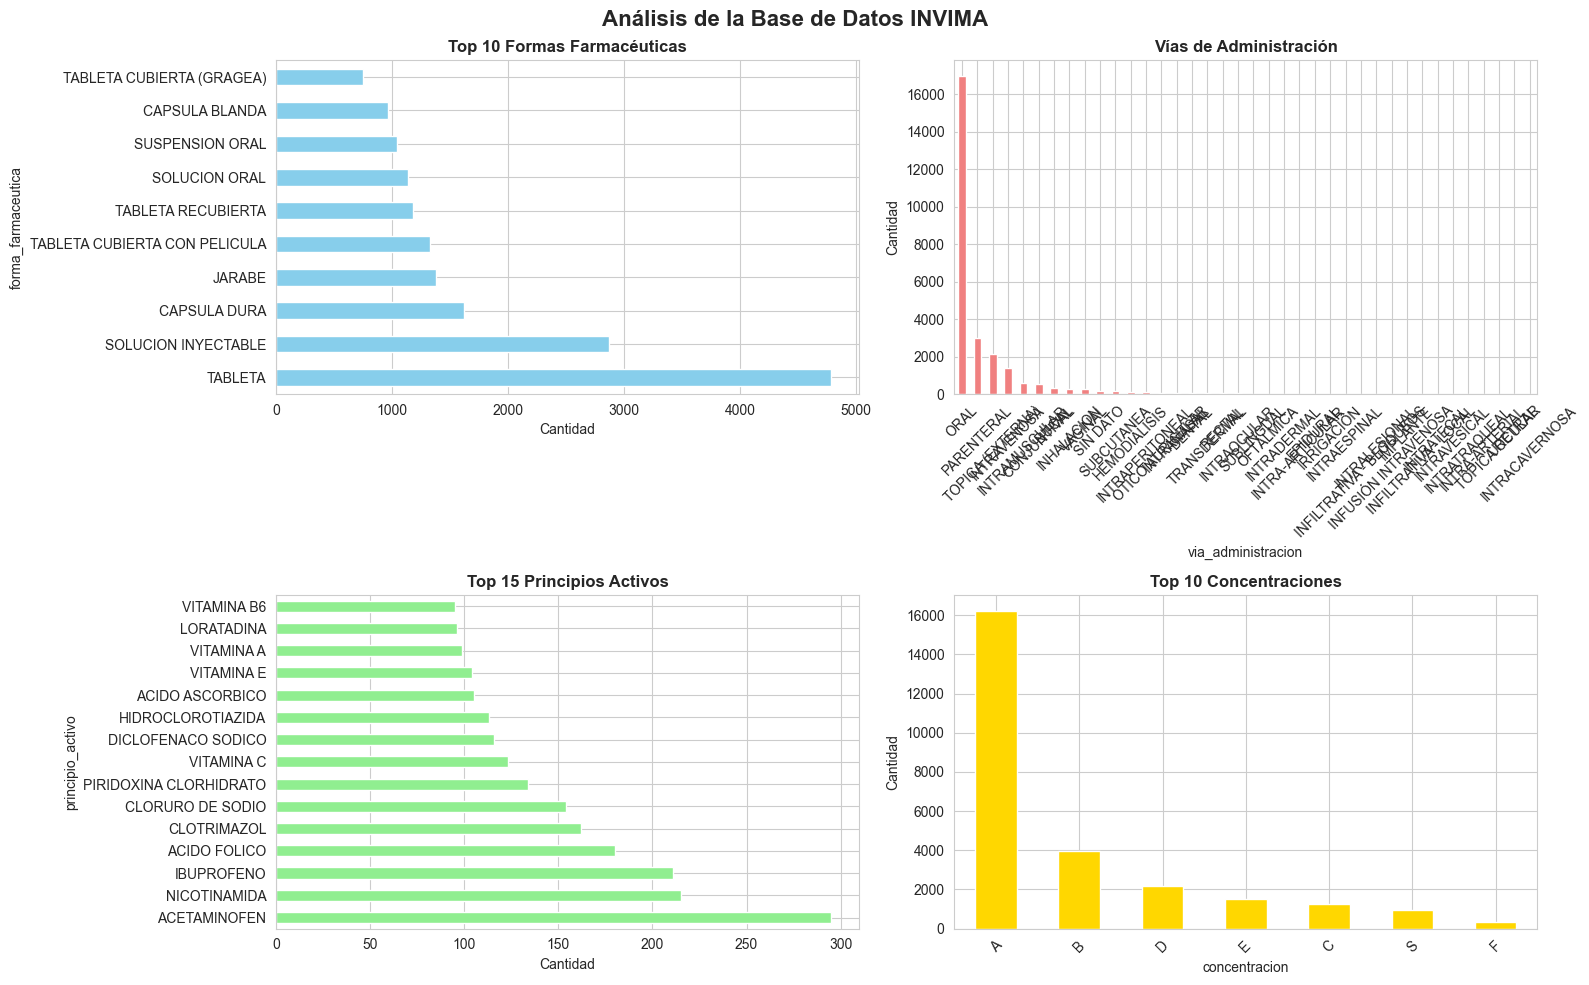

In [278]:
print("\n📊 ANÁLISIS ESTADÍSTICO DE LA BASE DE DATOS INVIMA")
print("="*80)

print(f"\n1. INFORMACIÓN GENERAL:")
print(f"   - Total de medicamentos: {len(df_clean):,}")

if 'principio_activo' in df_clean.columns:
    print(f"   - Principios activos únicos: {df_clean['principio_activo'].nunique():,}")

if 'forma_farmaceutica' in df_clean.columns:
    print(f"   - Formas farmacéuticas: {df_clean['forma_farmaceutica'].nunique()}")

if 'via_administracion' in df_clean.columns:
    print(f"   - Vías de administración: {df_clean['via_administracion'].nunique()}")

# Top formas farmacéuticas
if 'forma_farmaceutica' in df_clean.columns:
    print(f"\n2. TOP 10 FORMAS FARMACÉUTICAS:")
    top_formas = df_clean['forma_farmaceutica'].value_counts().head(10)
    for idx, (forma, count) in enumerate(top_formas.items(), 1):
        print(f"   {idx:2d}. {forma}: {count} medicamentos")

# Top vías de administración
if 'via_administracion' in df_clean.columns:
    print(f"\n3. VÍAS DE ADMINISTRACIÓN:")
    vias = df_clean['via_administracion'].value_counts()
    for idx, (via, count) in enumerate(vias.items(), 1):
        print(f"   {idx}. {via}: {count} medicamentos")

# Top principios activos
if 'principio_activo' in df_clean.columns:
    print(f"\n4. TOP 15 PRINCIPIOS ACTIVOS MÁS FRECUENTES:")
    top_principios = df_clean['principio_activo'].value_counts().head(15)
    for idx, (principio, count) in enumerate(top_principios.items(), 1):
        print(f"   {idx:2d}. {principio}: {count} medicamentos")

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análisis de la Base de Datos INVIMA', fontsize=16, fontweight='bold')

# Top formas
if 'forma_farmaceutica' in df_clean.columns:
    top_formas.head(10).plot(kind='barh', ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Top 10 Formas Farmacéuticas', fontweight='bold')
    axes[0, 0].set_xlabel('Cantidad')

# Vías de administración
if 'via_administracion' in df_clean.columns:
    vias.plot(kind='bar', ax=axes[0, 1], color='lightcoral')
    axes[0, 1].set_title('Vías de Administración', fontweight='bold')
    axes[0, 1].set_ylabel('Cantidad')
    axes[0, 1].tick_params(axis='x', rotation=45)

# Top principios activos
if 'principio_activo' in df_clean.columns:
    top_principios.head(15).plot(kind='barh', ax=axes[1, 0], color='lightgreen')
    axes[1, 0].set_title('Top 15 Principios Activos', fontweight='bold')
    axes[1, 0].set_xlabel('Cantidad')

# Top concentraciones
if 'concentracion' in df_clean.columns:
    concentraciones = df_clean['concentracion'].value_counts().head(10)
    concentraciones.plot(kind='bar', ax=axes[1, 1], color='gold')
    axes[1, 1].set_title('Top 10 Concentraciones', fontweight='bold')
    axes[1, 1].set_ylabel('Cantidad')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## PASO 13: Resumen Final

In [281]:
print("="*80)
print("RESUMEN FINAL - SISTEMA DE RECOMENDACION DE MEDICAMENTOS")
print("INVIMA CSV + OpenFDA + KNN")
print("="*80)

print("\nDATOS UTILIZADOS:")
print(f"   Archivo CSV: medicamentos_invima.csv")
print(f"   Medicamentos en BD: {len(df_clean):,}")
print(f"   Columnas detectadas: {len(rename_dict)}")

print("\nARQUITECTURA DEL SISTEMA:")
print(f"   Fuente 1: INVIMA (CSV local)")
print(f"   Fuente 2: OpenFDA (API de informacion farmacologica)")
print(f"   Algoritmo: KNN (K-Nearest Neighbors)")
print(f"   Vectorizacion: TF-IDF")
print(f"   Metricas: Cosine Similarity")

print("\nULTIMOS AJUSTES REALIZADOS:")
print(f"   Se corrigio el error de indices entre la seleccion y la recomendacion")
print(f"   Se separo la busqueda en dos modos: nombre comercial y principio activo + via")
print(f"   Se elimino el bloque repetido de detalle del medicamento consultado")
print(f"   La regla de recomendacion quedo en una funcion aparte")
print(f"   La busqueda por nombre comercial ahora va directo al medicamento elegido")
print(f"   La busqueda por principio activo pide tambien la via de administracion")
print(f"   Se ajusto el filtrado para devolver hasta 5 recomendaciones")

print("\nMODELO:")
print(f"   Dimensionalidad: {vectores.shape[1]} caracteristicas")
print(f"   Muestras indexadas: {vectores.shape[0]:,}")
print(f"   Vecinos KNN: 6")

print("\nCARACTERISTICAS DE BUSQUEDA:")
print(f"   Por nombre comercial")
print(f"   Por similitud de composicion")
print(f"   Por principio activo")
print(f"   Por via de administracion")

print("\nARTEFACTOS GENERADOS:")
print(f"   Modelo KNN entrenado")
print(f"   Vectorizador TF-IDF")
print(f"   Vectores de caracteristicas")
print(f"   Base de datos limpia en memoria")

print("\nFUNCIONES DISPONIBLES:")
print(f"   recomendar_medicamento_por_indice(nombre o indice)")
print(f"   listar_medicamentos_disponibles(filtro, limite)")

print("\nTIPO DE MODELO:")
print(f"   No supervisado (KNN)")
print(f"   Basado en metadata")
print(f"   Entrenamiento rapido")
print(f"   Prediccion inmediata")

print("\nPROXIMOS PASOS:")
print(f"   Afinar la normalizacion de principios activos")
print(f"   Reducir empates de similitud cuando los atributos son identicos")
print(f"   Mejorar la cobertura de sinimos comerciales")
print(f"   Volver a integrar fuentes externas si se necesita informacion farmacologica")

print("\n" + "="*80)
print("SISTEMA LISTO PARA USAR")
print("="*80)
print("\nInstrucciones de uso:")
print(f"1. Ejecutar las celdas de arriba hacia abajo")
print(f"2. Elegir busqueda por nombre comercial o por principio activo + via")
print(f"3. Revisar las recomendaciones generadas por KNN")

RESUMEN FINAL - SISTEMA DE RECOMENDACION DE MEDICAMENTOS
INVIMA CSV + OpenFDA + KNN

DATOS UTILIZADOS:
   Archivo CSV: medicamentos_invima.csv
   Medicamentos en BD: 26,414
   Columnas detectadas: 10

ARQUITECTURA DEL SISTEMA:
   Fuente 1: INVIMA (CSV local)
   Fuente 2: OpenFDA (API de informacion farmacologica)
   Algoritmo: KNN (K-Nearest Neighbors)
   Vectorizacion: TF-IDF
   Metricas: Cosine Similarity

ULTIMOS AJUSTES REALIZADOS:
   Se corrigio el error de indices entre la seleccion y la recomendacion
   Se separo la busqueda en dos modos: nombre comercial y principio activo + via
   Se elimino el bloque repetido de detalle del medicamento consultado
   La regla de recomendacion quedo en una funcion aparte
   La busqueda por nombre comercial ahora va directo al medicamento elegido
   La busqueda por principio activo pide tambien la via de administracion
   Se ajusto el filtrado para devolver hasta 5 recomendaciones

MODELO:
   Dimensionalidad: 5000 caracteristicas
   Muestras ind